<center> <H1>  CQF Final Project - Deep Learning for Financial Time Series </H1>
<center> <i> by Anna Grebenchtchikova

## Import Libraries

In [1]:
# Base Libraries
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
import datetime
import pandas_ta as ta
from pathlib import Path
plt.rcParams['figure.figsize'] = (12,8)
plt.style.use('fivethirtyeight')

# Import cufflinks for visualization
import cufflinks as cf
cf.set_config_file(offline=True)

# Import seaborn
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Import yahoo finance library
import yfinance as yf

# import boruta
from boruta import BorutaPy

# plotting & outputs
from pprint import pprint
import matplotlib.pyplot as plt
plt.style.use('seaborn')

# sklearn imports
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# SVM
from sklearn.svm import SVR, SVC

# Metrics
from sklearn.metrics import  r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import plot_confusion_matrix, auc, roc_curve, plot_roc_curve
from sklearn.metrics import f1_score, recall_score, precision_score


# import classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier

# tensorflow
import tensorflow
import tensorflow as tf
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator 

from tensorflow.keras.optimizers import Adam, RMSprop 
from tensorflow.keras.losses import BinaryCrossentropy 
from tensorflow.keras.metrics import BinaryAccuracy, Accuracy, AUC, Precision, Recall
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard
from tensorflow.keras.layers import Dropout, Dense, Flatten
from tensorflow.keras.layers import LSTM, BatchNormalization, GRU

# kerastuner
import keras_tuner as kt
from kerastuner import HyperParameter, HyperParameters
from kerastuner.tuners import RandomSearch, BayesianOptimization, Hyperband

pd.set_option('display.max_columns', 30)
pd.set_option('display.max_rows', 1000)

In [2]:
#Set a seed for consistency of results
def set_seeds(seed=2000): 
    random.seed(seed)
    np.random.seed(seed)
    tensorflow.random.set_seed(seed)
    tf.random.set_seed(seed)

In [3]:
random.seed(2000)
np.random.seed(2000)
tensorflow.random.set_seed(2000)
tf.random.set_seed(2000)

In [4]:
#load tensorboard
%load_ext tensorboard

# Clear any logs from previous runs
# rm -rf /logs

## Retrieve data

In [5]:
# Create a variable to predict for 'n' days
n = 5

### Create dataset

In [6]:
df = yf.download('CUKX.L',start='2015-01-01', end='2023-01-10', progress=0)
df['Returns'] = (df['Adj Close'].diff()/df['Adj Close'].shift(+1)).shift(-1)

df = df.dropna()
df

,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2015-01-02,8778.0,8884.200195,8751.620117,8752.5,8752.5,9022,-0.020794
2015-01-05,8758.0,8797.549805,8577.000000,8570.5,8570.5,12024,-0.005017
2015-01-06,8575.0,8644.000000,8497.160156,8527.5,8527.5,6014,0.006919
2015-01-07,8620.0,8655.000000,8579.440430,8586.5,8586.5,5120,0.025156
2015-01-08,8743.0,8906.000000,8695.309570,8802.5,8802.5,8882,-0.013746
...,...,...,...,...,...,...,...
2022-12-30,13500.0,13538.000000,13470.599609,13476.0,13476.0,1447,0.010686
2023-01-03,13564.0,13750.000000,13562.000000,13620.0,13620.0,6307,0.003524
2023-01-04,13638.0,13710.000000,13622.000000,13668.0,13668.0,14881,0.006438


In [7]:
df_excel = yf.download('CUKX.L',start='2015-01-01', end='2023-01-10', progress=0)
df_excel['Returns'] = (df_excel['Adj Close'].diff()/df_excel['Adj Close'].shift(+1)).shift(-1)
df_excel.to_excel('CUKX-FinalProjectCQF.xlsx', sheet_name='New Sheet')

In [8]:
df.head(2)

,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2015-01-02,8778.0,8884.200195,8751.620117,8752.5,8752.5,9022,-0.020794
2015-01-05,8758.0,8797.549805,8577.000000,8570.5,8570.5,12024,-0.005017


In [9]:
df.tail(2)

,Open,High,Low,Close,Adj Close,Volume,Returns
Date,,,,,,,
2023-01-05,13662.0,13796.0,13662.0,13756.0,13756.0,3224,0.009741
2023-01-06,13814.0,13890.0,13792.0,13890.0,13890.0,2812,0.002448


## Exploratory Data Analysis

### Descriptive Statistics

In [10]:
data = df.describe()
data.T

,count,mean,std,min,25%,50%,75%,max
Open,2025.0,10939.856266,1406.334052,7827.000000,9820.000000,11038.000000,11962.00000,1.381400e+04
High,2025.0,10994.438487,1401.728692,7827.000000,9874.030273,11072.440430,12012.00000,1.389000e+04
Low,2025.0,10880.707839,1410.552991,7671.439941,9750.000000,10994.000000,11892.00000,1.379200e+04
Close,2025.0,10937.752099,1408.262565,7721.000000,9811.000000,11030.000000,11954.00000,1.389000e+04
Adj Close,2025.0,10937.752099,1408.262565,7721.000000,9811.000000,11030.000000,11954.00000,1.389000e+04
Volume,2025.0,22590.661728,51819.487406,202.000000,7396.000000,13298.000000,23703.00000,1.429589e+06
Returns,2025.0,0.000287,0.010767,-0.095884,-0.004695,0.000625,0.00551,9.420643e-02


### Plotting the CUKX

In [11]:
df['Adj Close'].iplot(title='CKUX since January 1st 2015 (adjusted close)')

In [12]:
df['Returns'].iplot(kind='histogram', title='CUKX: Distribution of returns since January 1st 2015')

In [13]:
df['Returns'].iplot(kind='bar',title='CUKX: Daily returns since January 1st 2015')

## Cleaning Data

In [14]:
# Check for missing values
df.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Returns      0
dtype: int64

## Additional Feature Creation

In [15]:
# add all features for the pandas-ta technical library
df.ta.strategy('All')

131it [00:06, 18.87it/s]


In [16]:
df.ta.dpo(centered=False) # default of centered is True

Date
2015-01-02       NaN
2015-01-05       NaN
2015-01-06       NaN
2015-01-07       NaN
2015-01-08       NaN
               ...  
2022-12-30      9.55
2023-01-03    140.15
2023-01-04    180.45
2023-01-05    272.35
2023-01-06    407.45
Name: DPO_20, Length: 2025, dtype: float64

In [17]:
df.head()

,Open,High,Low,Close,Adj Close,Volume,Returns,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,ACCBM_20,ACCBU_20,AD,...,TTM_TRND_6,UI_14,UO_7_14_28,VAR_30,VHF_28,VIDYA_14,VTXP_14,VTXM_14,VWAP_D,VWMA_10,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-02,8778.0,8884.200195,8751.620117,8752.5,8752.5,9022,-0.020794,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8902.248936,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8796.106771,NaN,8785.205078,NaN,NaN,NaN,NaN
2015-01-05,8758.0,8797.549805,8577.000000,8570.5,8570.5,12024,-0.005017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-21634.986811,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8648.349935,NaN,8628.887451,NaN,NaN,NaN,NaN
2015-01-06,8575.0,8644.000000,8497.160156,8527.5,8527.5,6014,0.006919,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-25163.778224,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8556.220052,NaN,8549.040039,NaN,NaN,NaN,NaN
2015-01-07,8620.0,8655.000000,8579.440430,8586.5,8586.5,5120,0.025156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-29327.049649,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8606.980143,NaN,8601.860107,NaN,NaN,NaN,NaN
2015-01-08,8743.0,8906.000000,8695.309570,8802.5,8802.5,8882,-0.013746,8681.785352,NaN,NaN,NaN,NaN,NaN,NaN,-29171.473544,...,-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8801.269857,NaN,8801.577393,NaN,NaN,NaN,NaN


In [18]:
# check for missing values
df.isna().sum().sum()

10500

### Additional Data Cleaning

In [19]:
# drop unwanted columns
df.drop(['HILOl_13_21', 'HILOs_13_21', 'PSARl_0.02_0.2', 'PSARs_0.02_0.2', 
           'PSARaf_0.02_0.2', 'QQEl_14_5_4.236', 'QQEs_14_5_4.236', 'SUPERTl_7_3.0', 
           'SUPERTs_7_3.0'], axis=1, inplace=True)
df = df[100:]
df = df.bfill(axis=1)

In [20]:
# check for missing values
df.isna().sum().sum()

0

### Target Creation

In [21]:
df.shape

(1925, 216)

In [22]:
d_5 = (np.quantile(df['Returns'][:1540],q=0.5))
print(d_5)

0.0004384134406350383


In [23]:
# Target
y = np.where(df['Returns']>=d_5, 1,0)
df['Label'] = y
df.drop('Returns', axis=1, inplace=True)
df

,Open,High,Low,Close,Adj Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,ACCBM_20,ACCBU_20,AD,ADOSC_3_10,...,UI_14,UO_7_14_28,VAR_30,VHF_28,VIDYA_14,VTXP_14,VTXM_14,VWAP_D,VWMA_10,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30,Label
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-05-28,9484.0,9640.269531,9437.000000,9578.0,9578.0,1472.0,9552.905990,9720.758500,9385.053479,167.852510,9071.583206,9473.675,9902.318069,-4986.408754,-6844.775266,...,1.013710,47.831918,4961.719540,0.162071,8872.506151,1.021045,0.882055,9551.756510,9515.916656,9558.317383,-29.230769,9536.072727,9557.528416,1.175004,0
2015-05-29,9656.0,9678.000000,9484.099609,9477.0,9477.0,3029.0,9547.431250,9717.021922,9377.840578,169.590672,9066.778256,9477.400,9916.555844,-8237.220754,-6760.919939,...,1.046324,41.998251,4573.546264,0.162235,8880.160822,0.967652,0.924833,9546.366536,9515.853111,9529.024902,-60.909091,9528.636364,9524.705067,-0.208740,0
2015-06-01,9638.0,9638.000000,9398.519531,9449.0,9449.0,5498.0,9528.359245,9702.613333,9354.105156,174.254088,9050.256589,9478.200,9944.229245,-11417.356432,-7123.847753,...,1.090757,38.444541,4466.801437,0.168649,8887.555203,0.939353,0.946858,9495.173177,9510.158692,9483.629883,-69.393939,9516.027273,9509.849601,-0.575804,0
2015-06-02,9445.0,9519.709961,9390.000000,9427.0,9427.0,20414.0,9518.439909,9689.721952,9347.157866,171.282043,9068.638116,9477.150,9927.538263,-20185.095890,-9414.430982,...,1.036120,38.075079,4556.740230,0.167711,8891.476310,0.996578,0.954216,9445.569987,9488.242526,9440.927490,-76.060606,9499.563636,9466.967855,-0.881928,1
2015-06-03,9440.0,9507.900391,9412.000000,9466.0,9466.0,5290.0,9500.166602,9666.419352,9333.913851,166.252751,9082.698835,9480.100,9910.386579,-19517.664473,-9283.265853,...,0.959282,39.613706,4466.409195,0.169420,8898.374793,0.989589,1.011518,9461.966797,9485.279686,9462.975098,-64.242424,9490.954545,9446.428245,-0.270333,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-12-30,13500.0,13538.000000,13470.599609,13476.0,13476.0,1447.0,13501.906641,13644.863423,13358.949858,142.956782,13124.859263,13470.600,13809.749400,-898285.413722,-6185.325522,...,1.656561,59.990982,13941.679310,0.273990,13354.100309,0.947778,0.923760,13494.866536,13379.006700,13490.149902,-16.262136,13456.254545,13511.410234,0.160068,1
2023-01-03,13564.0,13750.000000,13562.000000,13620.0,13620.0,6307.0,13531.439974,13683.132971,13379.746977,151.692997,13110.469691,13470.550,13824.359827,-900700.860531,-6420.228266,...,1.618198,57.353427,12903.472414,0.251157,13358.956490,0.972533,0.834011,13644.000000,13403.763920,13638.000000,-13.485477,13494.145455,13560.608373,1.319618,1
2023-01-04,13638.0,13710.000000,13622.000000,13668.0,13668.0,14881.0,13570.373307,13717.953438,13422.793177,147.580130,13112.973305,13473.250,13828.363442,-900024.451440,-5717.446653,...,1.555385,50.877939,12997.688506,0.274818,13368.096954,0.994145,0.837573,13666.666667,13474.470195,13667.000000,-8.506224,13536.472727,13608.679578,1.625918,1


In [24]:
y

array([0, 0, 0, ..., 1, 1, 1])

In [25]:
# Value counts for class 1 and 0
pd.Series(y).value_counts()

1    971
0    954
dtype: int64

## Feature specification

In [26]:
X = df.drop('Label', axis=1)
feature_names = X.columns
X.tail()

,Open,High,Low,Close,Adj Close,Volume,ABER_ZG_5_15,ABER_SG_5_15,ABER_XG_5_15,ABER_ATR_5_15,ACCBL_20,ACCBM_20,ACCBU_20,AD,ADOSC_3_10,...,TTM_TRND_6,UI_14,UO_7_14_28,VAR_30,VHF_28,VIDYA_14,VTXP_14,VTXM_14,VWAP_D,VWMA_10,WCP,WILLR_14,WMA_10,ZL_EMA_10,ZS_30
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-12-30,13500.0,13538.0,13470.599609,13476.0,13476.0,1447.0,13501.906641,13644.863423,13358.949858,142.956782,13124.859263,13470.60,13809.749400,-898285.413722,-6185.325522,...,-1.0,1.656561,59.990982,13941.679310,0.273990,13354.100309,0.947778,0.923760,13494.866536,13379.006700,13490.149902,-16.262136,13456.254545,13511.410234,0.160068
2023-01-03,13564.0,13750.0,13562.000000,13620.0,13620.0,6307.0,13531.439974,13683.132971,13379.746977,151.692997,13110.469691,13470.55,13824.359827,-900700.860531,-6420.228266,...,1.0,1.618198,57.353427,12903.472414,0.251157,13358.956490,0.972533,0.834011,13644.000000,13403.763920,13638.000000,-13.485477,13494.145455,13560.608373,1.319618
2023-01-04,13638.0,13710.0,13622.000000,13668.0,13668.0,14881.0,13570.373307,13717.953438,13422.793177,147.580130,13112.973305,13473.25,13828.363442,-900024.451440,-5717.446653,...,1.0,1.555385,50.877939,12997.688506,0.274818,13368.096954,0.994145,0.837573,13666.666667,13474.470195,13667.000000,-8.506224,13536.472727,13608.679578,1.625918
2023-01-05,13662.0,13796.0,13662.000000,13756.0,13756.0,3224.0,13610.039974,13756.714762,13463.365186,146.674788,13110.811614,13479.45,13838.201751,-898725.227559,-4496.787790,...,1.0,1.533090,53.191371,14073.955172,0.315116,13379.352654,1.334274,0.796451,13738.000000,13529.046693,13742.500000,-6.329114,13586.545455,13671.828746,2.173919
2023-01-06,13814.0,13890.0,13792.000000,13890.0,13890.0,2812.0,13680.173307,13826.003110,13534.343505,145.829803,13120.325066,13495.55,13853.215203,-895913.227559,-2693.901183,...,1.0,1.504687,59.085455,18879.334483,0.370817,13401.051706,1.035484,0.706973,13857.333333,13595.742882,13865.500000,0.000000,13652.145455,13786.768974,2.737222


In [27]:
X.shape

(1925, 215)

## Split data in training and test

In [28]:
# Always keep shuffle = False for financial time series
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# convert to array
X_train, X_test, y_train, y_test = np.array(X_train), np.array(X_test), np.array(y_train), np.array(y_test) 

# Output the train and test data size
print(f"Train and Test Size {len(X_train)}, {len(X_test)}")

Train and Test Size 1540, 385


## Feature Selection

In [29]:
# test which forest depth fits best

# define random forest classifier
forest1 = RandomForestClassifier(n_estimators=1000,
                                n_jobs=-1,  
                                random_state=2000, 
                                max_depth=3)

# train the model
forest1.fit(X_train, y_train)

# print scores
print("Accuracy Score for depth 3 \t\t", accuracy_score(y_test, forest1.predict(X_test)))

# define random forest classifier
forest1 = RandomForestClassifier(n_estimators=1000,
                                n_jobs=-1,  
                                random_state=2000, 
                                max_depth=5)

# train the model
forest1.fit(X_train, y_train)

# print scores
print("Accuracy Score for depth 5 \t\t", accuracy_score(y_test, forest1.predict(X_test)))

# define random forest classifier
forest1 = RandomForestClassifier(n_estimators=1000,
                                n_jobs=-1,  
                                random_state=2000, 
                                max_depth=7)

# train the model
forest1.fit(X_train, y_train)

# print scores
print("Accuracy Score for depth 7 \t\t", accuracy_score(y_test, forest1.predict(X_test)))

Accuracy Score for depth 3 		 0.6311688311688312
Accuracy Score for depth 5 		 0.6285714285714286
Accuracy Score for depth 7 		 0.6207792207792208


In [30]:
# define list of maxium depths of the randomforest

# define random forest classifier
forest = RandomForestClassifier(n_estimators=1000,
                                n_jobs=-1,  
                                random_state=2000, 
                                max_depth=3)

# train the model
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=1000, n_jobs=-1,
                       random_state=2000)

In [31]:
# print scores
print("Accuracy Score \t\t", accuracy_score(y_test, forest.predict(X_test)))

Accuracy Score 		 0.6311688311688312


In [32]:
# define Boruta feature selection method
feat_selector = BorutaPy(forest, n_estimators='auto', verbose=1, random_state=2000, perc=95)

# find all relevant features
# takes input in array format not as dataframe
feat_selector.fit(X_train, y_train) 

Iteration: 1 / 100
Iteration: 2 / 100
Iteration: 3 / 100
Iteration: 4 / 100
Iteration: 5 / 100
Iteration: 6 / 100
Iteration: 7 / 100
Iteration: 8 / 100
Iteration: 9 / 100
Iteration: 10 / 100
Iteration: 11 / 100
Iteration: 12 / 100
Iteration: 13 / 100
Iteration: 14 / 100
Iteration: 15 / 100
Iteration: 16 / 100
Iteration: 17 / 100
Iteration: 18 / 100
Iteration: 19 / 100
Iteration: 20 / 100
Iteration: 21 / 100
Iteration: 22 / 100
Iteration: 23 / 100
Iteration: 24 / 100
Iteration: 25 / 100
Iteration: 26 / 100
Iteration: 27 / 100
Iteration: 28 / 100
Iteration: 29 / 100
Iteration: 30 / 100
Iteration: 31 / 100
Iteration: 32 / 100
Iteration: 33 / 100
Iteration: 34 / 100
Iteration: 35 / 100
Iteration: 36 / 100
Iteration: 37 / 100
Iteration: 38 / 100
Iteration: 39 / 100
Iteration: 40 / 100
Iteration: 41 / 100
Iteration: 42 / 100
Iteration: 43 / 100
Iteration: 44 / 100
Iteration: 45 / 100
Iteration: 46 / 100
Iteration: 47 / 100
Iteration: 48 / 100
Iteration: 49 / 100
Iteration: 50 / 100
Iteration

BorutaPy(estimator=RandomForestClassifier(max_depth=3, n_estimators=141,
                                          n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x18BF39ABD40),
         n_estimators='auto', perc=95,
         random_state=RandomState(MT19937) at 0x18BF39ABD40, verbose=1)

In [33]:
# call transform() on X to filter it down to selected features
X_filtered = feat_selector.transform(X_train)

In [34]:
type(feat_selector)

boruta.boruta_py.BorutaPy

In [35]:
# zip my names, ranks, and decisions in a single iterable
feature_ranks = list(zip(feature_names, 
                         feat_selector.ranking_, 
                         feat_selector.support_))

# iterate through and print out the results
for feat in feature_ranks:
    print(f'Feature: {feat[0]:<30} Rank: {feat[1]:<5} Keep: {feat[2]}')

Feature: Open                           Rank: 120   Keep: False
Feature: High                           Rank: 155   Keep: False
Feature: Low                            Rank: 132   Keep: False
Feature: Close                          Rank: 94    Keep: False
Feature: Adj Close                      Rank: 80    Keep: False
Feature: Volume                         Rank: 3     Keep: False
Feature: ABER_ZG_5_15                   Rank: 179   Keep: False
Feature: ABER_SG_5_15                   Rank: 157   Keep: False
Feature: ABER_XG_5_15                   Rank: 160   Keep: False
Feature: ABER_ATR_5_15                  Rank: 110   Keep: False
Feature: ACCBL_20                       Rank: 176   Keep: False
Feature: ACCBM_20                       Rank: 179   Keep: False
Feature: ACCBU_20                       Rank: 154   Keep: False
Feature: AD                             Rank: 33    Keep: False
Feature: ADOSC_3_10                     Rank: 109   Keep: False
Feature: ADX_14                         

In [36]:
rank1and2 = 0
for i in feat_selector.ranking_:
    if i == 1:
        rank1and2 += 1
    elif i == 2:
        rank1and2 += 1

In [37]:
selected_rf_features = pd.DataFrame({'Feature':feature_names,
                                     'Ranking':feat_selector.ranking_})

selected_rf_features.sort_values(by='Ranking').head(rank1and2)

,Feature,Ranking
65,DPO_20,1
211,WILLR_14,1
26,OBVe_12,1
93,ICS_26,2
112,MACDh_12_26_9,2
73,BEARP_13,2
133,PVI_1,2


## Compare the results on the Random Forest of Confirmed vs Confirmed & Tentative features

### Confirmed Features

In [38]:
# check the shape 
X_filtered.shape

(1540, 3)

In [39]:
# fit with selected features
forest.fit(X_filtered, y_train)

RandomForestClassifier(max_depth=3, n_estimators=141, n_jobs=-1,
                       random_state=RandomState(MT19937) at 0x18BF39ABD40)

In [40]:
# predict labels with unseen dataset
X_test_filtered = feat_selector.transform(X_test)
prediction = forest.predict(X_test_filtered)

In [41]:
# print scores
print("Accuracy Score \t\t", accuracy_score(y_test, prediction))

Accuracy Score 		 0.6545454545454545


### Confirmed and Tentative Features

In [42]:
X2 = X[['DPO_20', 'WILLR_14','OBVe_12','ICS_26','MACDh_12_26_9','BEARP_13','PVI_1']]
X2

,DPO_20,WILLR_14,OBVe_12,ICS_26,MACDh_12_26_9,BEARP_13,PVI_1
Date,,,,,,,
2015-05-28,151.775000,-29.230769,2.302458e+05,8989.0,8.207775,-77.697925,1000.022024
2015-05-29,66.000000,-60.909091,2.305835e+05,8895.0,2.159011,-25.212898,998.967524
2015-06-01,54.075000,-69.393939,2.300235e+05,8784.0,-3.742640,-102.176904,998.672072
2015-06-02,53.200000,-76.060606,2.264089e+05,8833.0,-8.851274,-100.168373,998.439243
2015-06-03,111.150000,-64.242424,2.241643e+05,9012.0,-9.282006,-74.715748,998.439243
...,...,...,...,...,...,...,...
2022-12-30,0.975143,-16.262136,-1.795719e+06,0.0,-8.925290,15.579582,953.592240
2023-01-03,0.975306,-13.485477,-1.793035e+06,1.0,0.165450,83.411405,954.660807
2023-01-04,0.948507,-8.506224,-1.788476e+06,1.0,8.361070,116.352633,955.013230


In [43]:
# create a training and test set
X2_train, X2_test, y_train, y_test = train_test_split(X2, y, test_size=0.2, shuffle=False)

# convert to array
X2_train, X2_test, y_train, y_test = np.array(X2_train), np.array(X2_test), np.array(y_train), np.array(y_test) 

In [44]:
# train the model
forest.fit(X2_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=141, n_jobs=-1,
                       random_state=RandomState(MT19937) at 0x18BF39ABD40)

In [45]:
# predict labels with unseen dataset
prediction2 = forest.predict(X2_test)

In [46]:
# print scores
print("Accuracy Score \t\t", accuracy_score(y_test, prediction2))

Accuracy Score 		 0.6467532467532467


### Correlation matrix

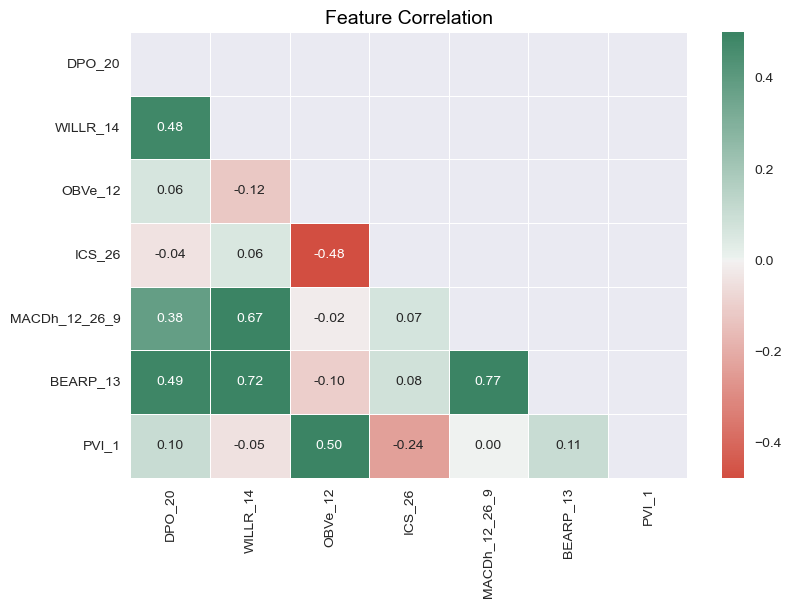

In [47]:
# Derive features correlation
corrmat = X2.corr()

# Visualize feature correlation
fig, ax = plt.subplots()

 # Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corrmat, dtype=bool))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(15, 150, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corrmat, annot=True, annot_kws={"size": 10}, 
            fmt="0.2f", cmap=cmap, mask = mask,vmax=.5, center=0,
            square=False, linewidths=.5, cbar_kws={"shrink": 1})

ax.set_title('Feature Correlation', fontsize=14, color='black');

### Multicollinearity Research

In [48]:
# load statmodels functions
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# compute the vif for all given features
def compute_vif(considered_features):
    
    X = df[considered_features]
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

In [49]:
# features to consider removing
considered_features = ['DPO_20', 'WILLR_14','OBVe_12','ICS_26','MACDh_12_26_9','BEARP_13','PVI_1']


# compute vif 
compute_vif(considered_features).sort_values('VIF', ascending=False)

,Variable,VIF
5,BEARP_13,3.478795
4,MACDh_12_26_9,2.792105
1,WILLR_14,2.417849
2,OBVe_12,1.742779
6,PVI_1,1.450925
0,DPO_20,1.411236
3,ICS_26,1.307399


## Resulting featureset

In [50]:
X3 = X[['DPO_20', 'WILLR_14','OBVe_12','ICS_26','MACDh_12_26_9','PVI_1']]
X3

,DPO_20,WILLR_14,OBVe_12,ICS_26,MACDh_12_26_9,PVI_1
Date,,,,,,
2015-05-28,151.775000,-29.230769,2.302458e+05,8989.0,8.207775,1000.022024
2015-05-29,66.000000,-60.909091,2.305835e+05,8895.0,2.159011,998.967524
2015-06-01,54.075000,-69.393939,2.300235e+05,8784.0,-3.742640,998.672072
2015-06-02,53.200000,-76.060606,2.264089e+05,8833.0,-8.851274,998.439243
2015-06-03,111.150000,-64.242424,2.241643e+05,9012.0,-9.282006,998.439243
...,...,...,...,...,...,...
2022-12-30,0.975143,-16.262136,-1.795719e+06,0.0,-8.925290,953.592240
2023-01-03,0.975306,-13.485477,-1.793035e+06,1.0,0.165450,954.660807
2023-01-04,0.948507,-8.506224,-1.788476e+06,1.0,8.361070,955.013230


In [51]:
# create a training and test set
X3_train, X3_test, y_train, y_test = train_test_split(X3, y, test_size=0.2, shuffle=False)

# convert to array
X3_train, X3_test, y_train, y_test = np.array(X3_train), np.array(X3_test), np.array(y_train), np.array(y_test) 

In [52]:
# train the model
forest.fit(X3_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=141, n_jobs=-1,
                       random_state=RandomState(MT19937) at 0x18BF39ABD40)

In [53]:
# predict labels with unseen dataset
prediction3 = forest.predict(X3_test)

In [54]:
# print scores
print("Accuracy Score \t\t", accuracy_score(y_test, prediction3))

Accuracy Score 		 0.6441558441558441


## Data exploration for determining feature scaling

In [55]:
X3.describe()

,DPO_20,WILLR_14,OBVe_12,ICS_26,MACDh_12_26_9,PVI_1
count,1925.000000,1925.000000,1.925000e+03,1925.000000,1925.000000,1925.000000
mean,-3.375267,-41.633774,-1.581508e+06,10899.986494,0.114314,976.955650
std,145.193499,30.100729,6.352194e+05,1874.182948,37.033726,15.444582
min,-787.300000,-110.614525,-2.910192e+06,0.000000,-260.232432,946.988907
25%,-76.000000,-65.368852,-1.906338e+06,10047.500000,-19.093269,961.264942
50%,0.967238,-38.682069,-1.717023e+06,11097.000000,-0.200373,981.683190
75%,75.000000,-13.778063,-1.442066e+06,12024.000000,21.636896,990.453980
max,994.525000,12.870370,2.305835e+05,13890.000000,166.826991,1000.022024


In [56]:
X3['DPO_20'].iplot(kind='histogram', title='CUKX DPO_20: Distribution since January 1st 2015')

In [57]:
X3['WILLR_14'].iplot(kind='histogram', title='CUKX WILLR_14: Distribution since January 1st 2015')

In [58]:
X3['OBVe_12'].iplot(kind='histogram', title='CUKX OBVe_12: Distribution since January 1st 2015')

In [59]:
X3['ICS_26'].iplot(kind='histogram', title='CUKX ICS_26: Distribution since January 1st 2015')

In [60]:
X3['MACDh_12_26_9'].iplot(kind='histogram', title='CUKX MACDh_12_26_9: Distribution since January 1st 2015')

In [61]:
X3['PVI_1'].iplot(kind='histogram', title='CUKX PVI_1: Distribution since January 1st 2015')

In [62]:
X3['ICS_26'].iplot(kind='line', title='CUKX ICS_26: Distribution since January 1st 2015')

In [63]:
X3['ICS_26'].tail(30)

Date
2022-11-23    13620.0
2022-11-24    13668.0
2022-11-25    13756.0
2022-11-28    13890.0
2022-11-29        1.0
2022-11-30        1.0
2022-12-01        0.0
2022-12-02        0.0
2022-12-05        1.0
2022-12-06        0.0
2022-12-07        0.0
2022-12-08        0.0
2022-12-09        1.0
2022-12-12        0.0
2022-12-13        1.0
2022-12-14        0.0
2022-12-15        0.0
2022-12-16        0.0
2022-12-19        1.0
2022-12-20        1.0
2022-12-21        1.0
2022-12-22        0.0
2022-12-23        1.0
2022-12-28        1.0
2022-12-29        1.0
2022-12-30        0.0
2023-01-03        1.0
2023-01-04        1.0
2023-01-05        1.0
2023-01-06        1.0
Name: ICS_26, dtype: float64

In [64]:
X4 = X3[:-26]
X4.shape

(1899, 6)

In [65]:
y = y[:-26]
y.shape

(1899,)

In [66]:
X4['ICS_26'].iplot(kind='histogram', title='CUKX ICS_26: Distribution since January 1st 2015')

### Accuracy after tweaking dataset

In [67]:
# create
X4_train, X4_test, y_train, y_test = train_test_split(X4, y, test_size=0.2, shuffle=False)

# convert to array
X4_train, X4_test, y_train, y_test = np.array(X4_train), np.array(X4_test), np.array(y_train), np.array(y_test) 

# Output the train and test data size
print(f"Train and Test Size {len(X4_train)}, {len(X4_test)}")

Train and Test Size 1519, 380


In [68]:
# train the model
forest.fit(X4_train, y_train)

RandomForestClassifier(max_depth=3, n_estimators=141, n_jobs=-1,
                       random_state=RandomState(MT19937) at 0x18BF39ABD40)

In [69]:
# predict labels with unseen dataset
prediction4 = forest.predict(X4_test)

In [70]:
print("Accuracy Score Test \t\t", accuracy_score(y_test, prediction4))

Accuracy Score Test 		 0.6447368421052632


In [71]:
# Value counts for class 1 and 0
pd.Series(y).value_counts()

1    958
0    941
dtype: int64

## Scaling

In [72]:
# combine all transformers
ct = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(), [0,4]),
        ('Normal', MinMaxScaler(), [1,3,5]),
        ('Robust', RobustScaler(), [2]),
    ])

In [73]:
# check transformed data
Xscaled = pd.DataFrame(ct.fit_transform(X4))
Xscaled

,0,1,2,3,4,5
0,1.065635,0.212522,0.659058,0.205544,1.000000,4.157397
1,0.477010,0.049539,0.402522,0.190306,0.980116,4.158119
2,0.395175,-0.109481,0.333811,0.172313,0.974545,4.156922
3,0.389170,-0.247133,0.279823,0.180256,0.970155,4.149199
4,0.786849,-0.258739,0.375529,0.209272,0.970155,4.144403
...,...,...,...,...,...,...
1894,-0.026694,0.613761,0.888591,0.932890,0.120930,-0.296581
1895,0.049479,0.606277,0.802752,0.956233,0.123741,-0.285697
1896,0.161680,0.583874,0.853025,0.964014,0.123741,-0.274517
1897,0.314713,0.548504,0.893585,0.978278,0.127802,-0.261418


In [74]:
X_scaled_train = pd.DataFrame(ct.fit_transform(X4_train))
X_scaled_train.shape

(1519, 6)

In [75]:
X_scaled_test = pd.DataFrame(ct.fit_transform(X4_test))
X_scaled_test.shape

(380, 6)

In [76]:
y_train.shape

(1519,)

In [77]:
y_test.shape

(380,)

### Generate sequences
Deep sequence modeling requires 3D shapes, so we'll have to reshape our data.

In [78]:
# generate train and test sequence data
# sequence length
seqlen = 21

# number of features
numfeat = X_scaled_train.shape[1]

g = TimeseriesGenerator(X_scaled_train, y_train, length=seqlen)
g_ = TimeseriesGenerator(X_scaled_test, y_test, length=seqlen)

In [79]:
# verify length
len(g), len(g_)

(12, 3)

In [80]:
# check feature set
g[0][0]

array([[[ 1.05936889e+00,  2.14578241e-01,  6.59058386e-01,
          2.62906904e-01,  1.00000000e+00,  4.52339856e+00],
        [ 4.71965085e-01,  5.35276473e-02,  4.02522382e-01,
          2.43416960e-01,  9.79877880e-01,  4.52421688e+00],
        [ 3.90300376e-01, -1.03606027e-01,  3.33810751e-01,
          2.20402239e-01,  9.74240019e-01,  4.52285976e+00],
        ...,
        [ 1.49731088e+00,  9.53531892e-02,  7.31381152e-01,
          2.78457392e-01,  9.46913521e-01,  4.45886218e+00],
        [ 1.67108379e+00,  3.16630453e-01,  7.13610653e-01,
          2.92763840e-01,  9.48753947e-01,  4.46869587e+00],
        [ 1.36805122e+00,  3.64180190e-01,  5.96294455e-01,
          3.00539084e-01,  9.48753947e-01,  4.47505212e+00]],

       [[ 4.71965085e-01,  5.35276473e-02,  4.02522382e-01,
          2.43416960e-01,  9.79877880e-01,  4.52421688e+00],
        [ 3.90300376e-01, -1.03606027e-01,  3.33810751e-01,
          2.20402239e-01,  9.74240019e-01,  4.52285976e+00],
        [ 3.84308

In [81]:
# check target 
g[0][1]

array([0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1])

In [82]:
# verify batch size
for i in range(len(g)):
    a, b = g[i]
    print(a.shape, b.shape)

(128, 21, 6) (128,)
(128, 21, 6) (128,)
(128, 21, 6) (128,)
(128, 21, 6) (128,)
(128, 21, 6) (128,)
(128, 21, 6) (128,)
(128, 21, 6) (128,)
(128, 21, 6) (128,)
(128, 21, 6) (128,)
(128, 21, 6) (128,)
(128, 21, 6) (128,)
(90, 21, 6) (90,)


## Baseline LSTM model

### Build baseline LSTM model

In [83]:
# Create a sequential model
def create_model(hu=256, lookback=21, features=1):
    
    tf.keras.backend.clear_session()

    # instantiate the model
    model = Sequential()
    
    model.add(LSTM(units=hu, input_shape=(lookback, features), activation = 'elu', return_sequences=False, name='LSTM'))
    
    model.add(Dense(units=1, activation = 'sigmoid', name='Output'))             
      
    # specify optimizer separately 
    opt = Adam(lr=0.001, epsilon=1e-08, decay=0.0)       
    
    # model compilation - 'binary_crossentropy' - 'accuracy' - BinaryAccuracy(name='accuracy', threshold=0.5)
    model.compile(optimizer=opt, 
                  loss=BinaryCrossentropy(), 
                  metrics=['accuracy', 
                           Precision(),
                           Recall()])

    return model

In [84]:
# lstm network
model = create_model(hu=10, lookback=seqlen, features=numfeat)

In [85]:
# summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 LSTM (LSTM)                 (None, 10)                680       
                                                                 
 Output (Dense)              (None, 1)                 11        
                                                                 
Total params: 691
Trainable params: 691
Non-trainable params: 0
_________________________________________________________________


### Model plot

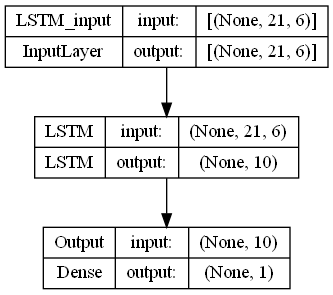

In [86]:
# plot layers
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

### Train the baseline model

In [87]:
results_path = Path('results', 'lstm_time_series')
if not results_path.exists():
    results_path.mkdir(parents=True)

# Specify callback functions
model_path = (results_path / 'model.h5').as_posix()
logdir = os.path.join("./tensorboard/logs", dt.datetime.now().strftime("%Y%m%d-%H%M%S"))

my_callbacks = [
    EarlyStopping(patience=10, monitor='loss', mode='min', verbose=1, restore_best_weights=True),
    ModelCheckpoint(filepath=model_path, verbose=1, monitor='loss', save_best_only=True),
    TensorBoard(log_dir=logdir, histogram_freq=1)]

In [88]:
# Model fitting
history = model.fit(g,
              epochs=500, 
              verbose=1, 
              callbacks=my_callbacks, 
              shuffle=False,
              batch_size = 32,
              )

Epoch 1/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.7194 - accuracy: 0.4852 - precision: 0.2727 - recall: 0.0156        
Epoch 1: loss improved from inf to 0.71633, saving model to results/lstm_time_series\model.h5
12/12 [==============================] - 3s 36ms/step - loss: 0.7163 - accuracy: 0.4853 - precision: 0.4017 - recall: 0.0628
Epoch 2/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.6989 - accuracy: 0.4696 - precision: 0.3701 - recall: 0.0813       
Epoch 2: loss improved from 0.71633 to 0.69775, saving model to results/lstm_time_series\model.h5
12/12 [==============================] - 0s 22ms/step - loss: 0.6977 - accuracy: 0.4753 - precision: 0.4312 - recall: 0.1591
Epoch 3/500
10/12 [========================>.....] - ETA: 0s - loss: 0.6884 - accuracy: 0.5109 - precision: 0.5152 - recall: 0.4237
Epoch 3: loss improved from 0.69775 to 0.68873, saving model to results/lstm_time_series\model.h5
12/12 [==============================] - 1s 22ms/

Epoch 25/500
10/12 [========================>.....] - ETA: 0s - loss: 0.6381 - accuracy: 0.6422 - precision: 0.6559 - recall: 0.6028
Epoch 25: loss did not improve from 0.63468
12/12 [==============================] - 0s 18ms/step - loss: 0.6399 - accuracy: 0.6389 - precision: 0.6436 - recall: 0.6203
Epoch 26/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.6351 - accuracy: 0.6406 - precision: 0.6178 - recall: 0.7439
Epoch 26: loss did not improve from 0.63468
12/12 [==============================] - 0s 19ms/step - loss: 0.6370 - accuracy: 0.6382 - precision: 0.6163 - recall: 0.7299
Epoch 27/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6342 - accuracy: 0.6342 - precision: 0.6473 - recall: 0.5875
Epoch 27: loss did not improve from 0.63468
12/12 [==============================] - 0s 16ms/step - loss: 0.6364 - accuracy: 0.6308 - precision: 0.6415 - recall: 0.5909
Epoch 28/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.6309 - accuracy: 0.647

12/12 [==============================] - 0s 26ms/step - loss: 0.6197 - accuracy: 0.6475 - precision: 0.6421 - recall: 0.6644
Epoch 50/500
10/12 [========================>.....] - ETA: 0s - loss: 0.6244 - accuracy: 0.6430 - precision: 0.6421 - recall: 0.6511
Epoch 50: loss improved from 0.61965 to 0.61807, saving model to results/lstm_time_series\model.h5
12/12 [==============================] - 0s 30ms/step - loss: 0.6181 - accuracy: 0.6489 - precision: 0.6468 - recall: 0.6537
Epoch 51/500
12/12 [==============================] - ETA: 0s - loss: 0.6190 - accuracy: 0.6455 - precision: 0.6396 - recall: 0.6644
Epoch 51: loss did not improve from 0.61807
12/12 [==============================] - 0s 21ms/step - loss: 0.6190 - accuracy: 0.6455 - precision: 0.6396 - recall: 0.6644
Epoch 52/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6243 - accuracy: 0.6506 - precision: 0.6522 - recall: 0.6430
Epoch 52: loss did not improve from 0.61807
12/12 [==============================] 

Epoch 75/500
10/12 [========================>.....] - ETA: 0s - loss: 0.6203 - accuracy: 0.6383 - precision: 0.6375 - recall: 0.6464
Epoch 75: loss improved from 0.60826 to 0.60665, saving model to results/lstm_time_series\model.h5
12/12 [==============================] - 0s 19ms/step - loss: 0.6066 - accuracy: 0.6489 - precision: 0.6468 - recall: 0.6537
Epoch 76/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6187 - accuracy: 0.6435 - precision: 0.6406 - recall: 0.6515
Epoch 76: loss did not improve from 0.60665
12/12 [==============================] - 0s 16ms/step - loss: 0.6084 - accuracy: 0.6515 - precision: 0.6479 - recall: 0.6618
Epoch 77/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6166 - accuracy: 0.6477 - precision: 0.6494 - recall: 0.6401
Epoch 77: loss did not improve from 0.60665
12/12 [==============================] - 0s 17ms/step - loss: 0.6075 - accuracy: 0.6555 - precision: 0.6559 - recall: 0.6524
Epoch 78/500
11/12 [===================

In [89]:
#evaluate the model on the test data

score_train = model.evaluate(g, verbose=100)

print ('Loss:', round(score_train[0], 3))
print ('Accuracy:', round(score_train[1], 3))
print ('Precision:', round(score_train[2], 3))
print ('Recall:', round(score_train[3], 3))
print (' ')

score_test = model.evaluate(g_, verbose=100)

print ('Loss:', round(score_test[0], 3))
print ('Accuracy:', round(score_test[1], 3))
print ('Precision:', round(score_test[2], 3))
print ('Recall:', round(score_test[3], 3))


Loss: 0.606
Accuracy: 0.655
Precision: 0.645
Recall: 0.687
 
Loss: 0.642
Accuracy: 0.638
Precision: 0.641
Recall: 0.702


In [90]:
# %tensorboard --logdir .logs

## Model Comparison

### Stacked LSTM (3 layers)

In [91]:
# Create a sequential model
def create_model(hu=256, lookback=21, features=1):
    
    tf.keras.backend.clear_session()   

    # instantiate the model
    model = Sequential()
    
    model.add(LSTM(units=hu*2, input_shape=(lookback, features), activation = 'elu', return_sequences=True, name='LSTM'))
    model.add(Dropout(0.3, name='Dropout1'))
    
    model.add(LSTM(units=hu, activation = 'elu', return_sequences=True, name='LSTM2'))
    model.add(Dropout(0.3, name='Dropout2'))
    
    model.add(LSTM(units=hu, activation = 'elu', return_sequences=False, name='LSTM3'))
    
    model.add(Dense(units=1, activation='sigmoid', name='Output'))             
    
    # specify optimizer separately
    opt = Adam(lr=0.001, epsilon=1e-08, decay=0.0)       
    
    # model compilation - 'binary_crossentropy' - 'accuracy' - BinaryAccuracy(name='accuracy', threshold=0.5)
    model.compile(optimizer=opt, 
                  loss=BinaryCrossentropy(), 
                  metrics=['accuracy', 
                           Precision(),
                           Recall()])

    return model



In [92]:
# lstm network
model = create_model(hu=10, lookback=seqlen, features=numfeat)

In [93]:
# summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 LSTM (LSTM)                 (None, 21, 20)            2160      
                                                                 
 Dropout1 (Dropout)          (None, 21, 20)            0         
                                                                 
 LSTM2 (LSTM)                (None, 21, 10)            1240      
                                                                 
 Dropout2 (Dropout)          (None, 21, 10)            0         
                                                                 
 LSTM3 (LSTM)                (None, 10)                840       
                                                                 
 Output (Dense)              (None, 1)                 11        
                                                                 
Total params: 4,251
Trainable params: 4,251
Non-trainabl

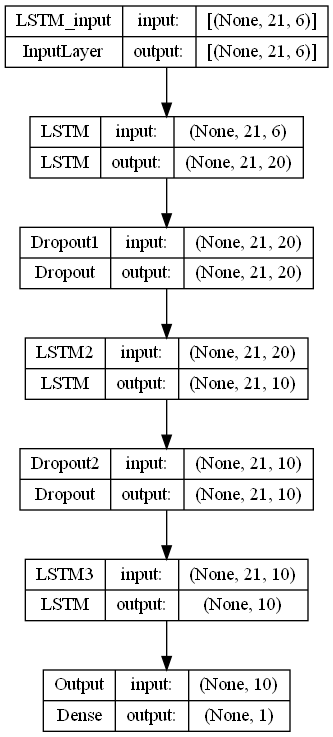

In [94]:
# plot layers
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [95]:
# Model fitting
model.fit(g,
          epochs=500, 
          verbose=1, 
          callbacks=my_callbacks, 
          shuffle=False,
          batch_size = 32
          )

Epoch 1/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6960 - accuracy: 0.4986 - precision: 0.4615 - recall: 0.0256     
Epoch 1: loss did not improve from 0.60665
12/12 [==============================] - 5s 50ms/step - loss: 0.6958 - accuracy: 0.4987 - precision: 0.4615 - recall: 0.0241
Epoch 2/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6914 - accuracy: 0.5163 - precision: 0.5235 - recall: 0.3485    
Epoch 2: loss did not improve from 0.60665
12/12 [==============================] - 1s 42ms/step - loss: 0.6915 - accuracy: 0.5154 - precision: 0.5224 - recall: 0.3422
Epoch 3/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6904 - accuracy: 0.5490 - precision: 0.5334 - recall: 0.7724    
Epoch 3: loss did not improve from 0.60665
12/12 [==============================] - 1s 42ms/step - loss: 0.6905 - accuracy: 0.5467 - precision: 0.5322 - recall: 0.7634
Epoch 4/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6890 - accuracy:

12/12 [==============================] - ETA: 0s - loss: 0.6550 - accuracy: 0.6162 - precision: 0.6183 - recall: 0.6043
Epoch 28: loss did not improve from 0.60665
12/12 [==============================] - 1s 50ms/step - loss: 0.6550 - accuracy: 0.6162 - precision: 0.6183 - recall: 0.6043
Epoch 29/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6492 - accuracy: 0.6136 - precision: 0.6137 - recall: 0.6102
Epoch 29: loss did not improve from 0.60665
12/12 [==============================] - 1s 51ms/step - loss: 0.6527 - accuracy: 0.6095 - precision: 0.6100 - recall: 0.6043
Epoch 30/500
12/12 [==============================] - ETA: 0s - loss: 0.6522 - accuracy: 0.6115 - precision: 0.6098 - recall: 0.6163
Epoch 30: loss did not improve from 0.60665
12/12 [==============================] - 1s 49ms/step - loss: 0.6522 - accuracy: 0.6115 - precision: 0.6098 - recall: 0.6163
Epoch 31/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6536 - accuracy: 0.6158 - precision

11/12 [==========================>...] - ETA: 0s - loss: 0.6372 - accuracy: 0.6271 - precision: 0.6229 - recall: 0.6415Restoring model weights from the end of the best epoch: 45.

Epoch 55: loss did not improve from 0.60665
12/12 [==============================] - 1s 50ms/step - loss: 0.6400 - accuracy: 0.6262 - precision: 0.6247 - recall: 0.6297
Epoch 55: early stopping


In [96]:
#evaluate the model on the test data

score_train = model.evaluate(g, verbose=100)

print ('Loss:', round(score_train[0], 3))
print ('Accuracy:', round(score_train[1], 3))
print ('Precision:', round(score_train[2], 3))
print ('Recall:', round(score_train[3], 3))
print (' ')

score_test = model.evaluate(g_, verbose=100)

print ('Loss:', round(score_test[0], 3))
print ('Accuracy:', round(score_test[1], 3))
print ('Precision:', round(score_test[2], 3))
print ('Recall:', round(score_test[3], 3))


Loss: 0.636
Accuracy: 0.634
Precision: 0.625
Recall: 0.67
 
Loss: 0.659
Accuracy: 0.604
Precision: 0.616
Recall: 0.649


### Stacked LSTM (5 layers)

In [97]:
# Create a sequential model
def create_model(hu=256, lookback=21, features=1):
    
    tf.keras.backend.clear_session()   

    # instantiate the model
    model = Sequential()
    
    model.add(LSTM(units=hu*2, input_shape=(lookback, features), activation = 'elu', return_sequences=True, name='LSTM'))
    model.add(Dropout(0.3, name='Dropout1'))
    
    model.add(LSTM(units=hu, activation = 'elu', return_sequences=True, name='LSTM2'))
    model.add(Dropout(0.3, name='Dropout2'))
    
    model.add(LSTM(units=hu, activation = 'elu', return_sequences=True, name='LSTM3'))
    model.add(Dropout(0.3, name='Dropout3'))
    
    model.add(LSTM(units=hu, activation = 'elu', return_sequences=True, name='LSTM4'))
    model.add(Dropout(0.3, name='Dropout4'))
    
    model.add(LSTM(units=hu, activation = 'elu', return_sequences=False, name='LSTM5'))
    
    model.add(Dense(units=1, activation='sigmoid', name='Output'))             
    
    # specify optimizer separately
    opt = Adam(lr=0.001, epsilon=1e-08, decay=0.0)       
    
    # model compilation - 'binary_crossentropy' - 'accuracy' - BinaryAccuracy(name='accuracy', threshold=0.5)
    model.compile(optimizer=opt, 
                  loss=BinaryCrossentropy(), 
                  metrics=['accuracy', 
                           Precision(),
                           Recall()])

    return model



In [98]:
# lstm network
model = create_model(hu=10, lookback=seqlen, features=numfeat)

In [99]:
# summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 LSTM (LSTM)                 (None, 21, 20)            2160      
                                                                 
 Dropout1 (Dropout)          (None, 21, 20)            0         
                                                                 
 LSTM2 (LSTM)                (None, 21, 10)            1240      
                                                                 
 Dropout2 (Dropout)          (None, 21, 10)            0         
                                                                 
 LSTM3 (LSTM)                (None, 21, 10)            840       
                                                                 
 Dropout3 (Dropout)          (None, 21, 10)            0         
                                                                 
 LSTM4 (LSTM)                (None, 21, 10)            8

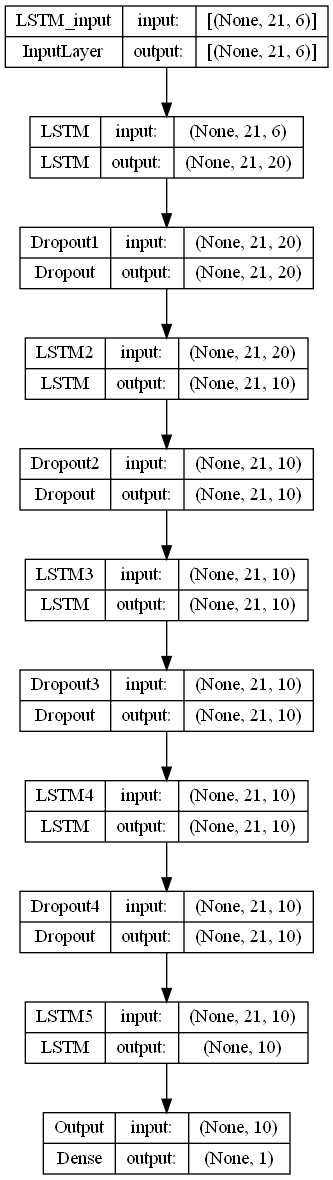

In [100]:
# plot layers
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [101]:
# Model fitting
model.fit(g,
          epochs=500, 
          verbose=1, 
          callbacks=my_callbacks, 
          shuffle=False,
          batch_size = 32
          )

Epoch 1/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6940 - accuracy: 0.5078 - precision: 0.5044 - recall: 0.8193
Epoch 1: loss did not improve from 0.60665
12/12 [==============================] - 8s 75ms/step - loss: 0.6940 - accuracy: 0.5067 - precision: 0.5039 - recall: 0.7767
Epoch 2/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6933 - accuracy: 0.5050 - precision: 0.5046 - recall: 0.4651
Epoch 2: loss did not improve from 0.60665
12/12 [==============================] - 1s 73ms/step - loss: 0.6933 - accuracy: 0.5053 - precision: 0.5054 - recall: 0.4398
Epoch 3/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6929 - accuracy: 0.5121 - precision: 0.5149 - recall: 0.3926
Epoch 3: loss did not improve from 0.60665
12/12 [==============================] - 1s 67ms/step - loss: 0.6929 - accuracy: 0.5100 - precision: 0.5125 - recall: 0.3850
Epoch 4/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6926 - accuracy: 0.5071 - pre

12/12 [==============================] - ETA: 0s - loss: 0.6650 - accuracy: 0.6028 - precision: 0.5965 - recall: 0.6324
Epoch 28: loss did not improve from 0.60665
12/12 [==============================] - 1s 115ms/step - loss: 0.6650 - accuracy: 0.6028 - precision: 0.5965 - recall: 0.6324
Epoch 29/500
12/12 [==============================] - ETA: 0s - loss: 0.6677 - accuracy: 0.5861 - precision: 0.5879 - recall: 0.5722
Epoch 29: loss did not improve from 0.60665
12/12 [==============================] - 1s 112ms/step - loss: 0.6677 - accuracy: 0.5861 - precision: 0.5879 - recall: 0.5722
Epoch 30/500
12/12 [==============================] - ETA: 0s - loss: 0.6640 - accuracy: 0.6061 - precision: 0.6023 - recall: 0.6217
Epoch 30: loss did not improve from 0.60665
12/12 [==============================] - 1s 81ms/step - loss: 0.6640 - accuracy: 0.6061 - precision: 0.6023 - recall: 0.6217
Epoch 31/500
12/12 [==============================] - ETA: 0s - loss: 0.6667 - accuracy: 0.6021 - precisi

12/12 [==============================] - ETA: 0s - loss: 0.6546 - accuracy: 0.6095 - precision: 0.6143 - recall: 0.5856
Epoch 55: loss did not improve from 0.60665
12/12 [==============================] - 1s 81ms/step - loss: 0.6546 - accuracy: 0.6095 - precision: 0.6143 - recall: 0.5856
Epoch 56/500
12/12 [==============================] - ETA: 0s - loss: 0.6496 - accuracy: 0.6202 - precision: 0.6109 - recall: 0.6591
Epoch 56: loss did not improve from 0.60665
12/12 [==============================] - 1s 76ms/step - loss: 0.6496 - accuracy: 0.6202 - precision: 0.6109 - recall: 0.6591
Epoch 57/500
12/12 [==============================] - ETA: 0s - loss: 0.6541 - accuracy: 0.6262 - precision: 0.6295 - recall: 0.6110
Epoch 57: loss did not improve from 0.60665
12/12 [==============================] - 1s 118ms/step - loss: 0.6541 - accuracy: 0.6262 - precision: 0.6295 - recall: 0.6110
Epoch 58/500
12/12 [==============================] - ETA: 0s - loss: 0.6548 - accuracy: 0.6188 - precisio

11/12 [==========================>...] - ETA: 0s - loss: 0.6426 - accuracy: 0.6321 - precision: 0.6216 - recall: 0.6728
Epoch 82: loss did not improve from 0.60665
12/12 [==============================] - 1s 69ms/step - loss: 0.6445 - accuracy: 0.6302 - precision: 0.6203 - recall: 0.6684
Epoch 83/500
12/12 [==============================] - ETA: 0s - loss: 0.6448 - accuracy: 0.6275 - precision: 0.6381 - recall: 0.5869
Epoch 83: loss did not improve from 0.60665
12/12 [==============================] - 1s 68ms/step - loss: 0.6448 - accuracy: 0.6275 - precision: 0.6381 - recall: 0.5869
Epoch 84/500
12/12 [==============================] - ETA: 0s - loss: 0.6384 - accuracy: 0.6282 - precision: 0.6268 - recall: 0.6310
Epoch 84: loss did not improve from 0.60665
12/12 [==============================] - 1s 74ms/step - loss: 0.6384 - accuracy: 0.6282 - precision: 0.6268 - recall: 0.6310
Epoch 85/500
12/12 [==============================] - ETA: 0s - loss: 0.6390 - accuracy: 0.6302 - precision

11/12 [==========================>...] - ETA: 0s - loss: 0.6283 - accuracy: 0.6484 - precision: 0.6512 - recall: 0.6373
Epoch 109: loss did not improve from 0.60665
12/12 [==============================] - 1s 67ms/step - loss: 0.6322 - accuracy: 0.6402 - precision: 0.6433 - recall: 0.6270
Epoch 110/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6173 - accuracy: 0.6562 - precision: 0.6667 - recall: 0.6230
Epoch 110: loss did not improve from 0.60665
12/12 [==============================] - 1s 68ms/step - loss: 0.6212 - accuracy: 0.6529 - precision: 0.6629 - recall: 0.6203
Epoch 111/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6284 - accuracy: 0.6605 - precision: 0.6535 - recall: 0.6814
Epoch 111: loss did not improve from 0.60665
12/12 [==============================] - 1s 71ms/step - loss: 0.6322 - accuracy: 0.6535 - precision: 0.6474 - recall: 0.6725
Epoch 112/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6301 - accuracy: 0.6442 - pre

In [102]:
#evaluate the model on the test data

score_train = model.evaluate(g, verbose=100)

print ('Loss:', round(score_train[0], 3))
print ('Accuracy:', round(score_train[1], 3))
print ('Precision:', round(score_train[2], 3))
print ('Recall:', round(score_train[3], 3))
print (' ')

score_test = model.evaluate(g_, verbose=100)

print ('Loss:', round(score_test[0], 3))
print ('Accuracy:', round(score_test[1], 3))
print ('Precision:', round(score_test[2], 3))
print ('Recall:', round(score_test[3], 3))


Loss: 0.611
Accuracy: 0.667
Precision: 0.661
Recall: 0.683
 
Loss: 0.674
Accuracy: 0.602
Precision: 0.63
Recall: 0.58


### GRU - 1 layer

In [103]:
# Create a sequential model
def create_model(hu=256, lookback=21, features=1):
    
    tf.keras.backend.clear_session()   

    # instantiate the model
    model = Sequential()
    
    model.add(GRU(units=hu, input_shape=(lookback, features), activation = 'elu', return_sequences=False, name='GRU'))
#     model.add(Dropout(0.3, name='Dropout1'))
    
#     model.add(LSTM(units=hu, activation = 'elu', return_sequences=True, name='LSTM2'))
#     model.add(Dropout(0.3, name='Dropout2'))
    
#     model.add(LSTM(units=hu, activation = 'elu', return_sequences=False, name='LSTM3'))
    
    model.add(Dense(units=1, activation='sigmoid', name='Output'))             
    
    # specify optimizer separately
    opt = Adam(lr=0.001, epsilon=1e-08, decay=0.0)       
    
    # model compilation - 'binary_crossentropy' - 'accuracy' - BinaryAccuracy(name='accuracy', threshold=0.5)
    model.compile(optimizer=opt, 
                  loss=BinaryCrossentropy(), 
                  metrics=['accuracy', 
                           Precision(),
                           Recall()])

    return model

In [104]:
# gru network
model = create_model(hu=10, lookback=seqlen, features=numfeat)

In [105]:
# summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 GRU (GRU)                   (None, 10)                540       
                                                                 
 Output (Dense)              (None, 1)                 11        
                                                                 
Total params: 551
Trainable params: 551
Non-trainable params: 0
_________________________________________________________________


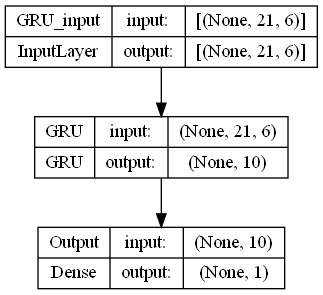

In [106]:
# plot layers
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [107]:
# Model fitting
model.fit(g,
          epochs=500, 
          verbose=1, 
          callbacks=my_callbacks, 
          shuffle=False,
          batch_size = 32
          )

Epoch 1/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.6950 - accuracy: 0.5417 - precision: 0.5260 - recall: 0.8754
Epoch 1: loss did not improve from 0.60665
12/12 [==============================] - 3s 27ms/step - loss: 0.7071 - accuracy: 0.5487 - precision: 0.5301 - recall: 0.8476
Epoch 2/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6758 - accuracy: 0.5611 - precision: 0.5459 - recall: 0.7183
Epoch 2: loss did not improve from 0.60665
12/12 [==============================] - 0s 16ms/step - loss: 0.6818 - accuracy: 0.5574 - precision: 0.5419 - recall: 0.7353
Epoch 3/500
10/12 [========================>.....] - ETA: 0s - loss: 0.6661 - accuracy: 0.5969 - precision: 0.5875 - recall: 0.6589
Epoch 3: loss did not improve from 0.60665
12/12 [==============================] - 0s 16ms/step - loss: 0.6702 - accuracy: 0.5915 - precision: 0.5771 - recall: 0.6805
Epoch 4/500
10/12 [========================>.....] - ETA: 0s - loss: 0.6621 - accuracy: 0.6031 - pre

11/12 [==========================>...] - ETA: 0s - loss: 0.6377 - accuracy: 0.6420 - precision: 0.6380 - recall: 0.6543
Epoch 28: loss did not improve from 0.60665
12/12 [==============================] - 0s 35ms/step - loss: 0.6394 - accuracy: 0.6395 - precision: 0.6344 - recall: 0.6564
Epoch 29/500
12/12 [==============================] - ETA: 0s - loss: 0.6391 - accuracy: 0.6422 - precision: 0.6370 - recall: 0.6591
Epoch 29: loss did not improve from 0.60665
12/12 [==============================] - 0s 31ms/step - loss: 0.6391 - accuracy: 0.6422 - precision: 0.6370 - recall: 0.6591
Epoch 30/500
10/12 [========================>.....] - ETA: 0s - loss: 0.6380 - accuracy: 0.6445 - precision: 0.6398 - recall: 0.6667
Epoch 30: loss did not improve from 0.60665
12/12 [==============================] - 0s 20ms/step - loss: 0.6387 - accuracy: 0.6422 - precision: 0.6373 - recall: 0.6578
Epoch 31/500
12/12 [==============================] - ETA: 0s - loss: 0.6384 - accuracy: 0.6429 - precision

12/12 [==============================] - ETA: 0s - loss: 0.6296 - accuracy: 0.6469 - precision: 0.6413 - recall: 0.6644
Epoch 55: loss did not improve from 0.60665
12/12 [==============================] - 0s 20ms/step - loss: 0.6296 - accuracy: 0.6469 - precision: 0.6413 - recall: 0.6644
Epoch 56/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.6267 - accuracy: 0.6493 - precision: 0.6417 - recall: 0.6817
Epoch 56: loss did not improve from 0.60665
12/12 [==============================] - 0s 19ms/step - loss: 0.6293 - accuracy: 0.6449 - precision: 0.6399 - recall: 0.6604
Epoch 57/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.6264 - accuracy: 0.6484 - precision: 0.6411 - recall: 0.6799
Epoch 57: loss did not improve from 0.60665
12/12 [==============================] - 0s 19ms/step - loss: 0.6290 - accuracy: 0.6462 - precision: 0.6412 - recall: 0.6618
Epoch 58/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.6262 - accuracy: 0.6502 - precision

10/12 [========================>.....] - ETA: 0s - loss: 0.6209 - accuracy: 0.6461 - precision: 0.6452 - recall: 0.6542
Epoch 82: loss did not improve from 0.60665
12/12 [==============================] - 0s 26ms/step - loss: 0.6225 - accuracy: 0.6475 - precision: 0.6467 - recall: 0.6484
Epoch 83/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6196 - accuracy: 0.6491 - precision: 0.6504 - recall: 0.6430
Epoch 83: loss did not improve from 0.60665
12/12 [==============================] - 0s 22ms/step - loss: 0.6222 - accuracy: 0.6475 - precision: 0.6478 - recall: 0.6444
Epoch 84/500
10/12 [========================>.....] - ETA: 0s - loss: 0.6204 - accuracy: 0.6453 - precision: 0.6446 - recall: 0.6526
Epoch 84: loss did not improve from 0.60665
12/12 [==============================] - 0s 27ms/step - loss: 0.6220 - accuracy: 0.6469 - precision: 0.6462 - recall: 0.6471
Epoch 85/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.6203 - accuracy: 0.6458 - precision

10/12 [========================>.....] - ETA: 0s - loss: 0.6138 - accuracy: 0.6531 - precision: 0.6571 - recall: 0.6449
Epoch 109: loss did not improve from 0.60665
12/12 [==============================] - 0s 32ms/step - loss: 0.6153 - accuracy: 0.6542 - precision: 0.6584 - recall: 0.6390
Epoch 110/500
12/12 [==============================] - ETA: 0s - loss: 0.6150 - accuracy: 0.6569 - precision: 0.6607 - recall: 0.6430
Epoch 110: loss did not improve from 0.60665
12/12 [==============================] - 0s 34ms/step - loss: 0.6150 - accuracy: 0.6569 - precision: 0.6607 - recall: 0.6430
Epoch 111/500
10/12 [========================>.....] - ETA: 0s - loss: 0.6131 - accuracy: 0.6539 - precision: 0.6577 - recall: 0.6464
Epoch 111: loss did not improve from 0.60665
12/12 [==============================] - 0s 29ms/step - loss: 0.6146 - accuracy: 0.6549 - precision: 0.6589 - recall: 0.6404
Epoch 112/500
12/12 [==============================] - ETA: 0s - loss: 0.6143 - accuracy: 0.6562 - pre

...

Epoch 210/500
12/12 [==============================] - ETA: 0s - loss: 0.6056 - accuracy: 0.6595 - precision: 0.6755 - recall: 0.6123
Epoch 210: loss did not improve from 0.58535
12/12 [==============================] - 0s 32ms/step - loss: 0.6056 - accuracy: 0.6595 - precision: 0.6755 - recall: 0.6123
Epoch 211/500
10/12 [========================>.....] - ETA: 0s - loss: 0.5874 - accuracy: 0.6727 - precision: 0.6767 - recall: 0.6651
Epoch 211: loss did not improve from 0.58535
12/12 [==============================] - 0s 24ms/step - loss: 0.5905 - accuracy: 0.6682 - precision: 0.6698 - recall: 0.6618
Epoch 212/500
12/12 [==============================] - ETA: 0s - loss: 0.5866 - accuracy: 0.6642 - precision: 0.6753 - recall: 0.6310
Epoch 212: loss did not improve from 0.58535
12/12 [==============================] - 0s 32ms/step - loss: 0.5866 - accuracy: 0.6642 - precision: 0.6753 - recall: 0.6310
Epoch 213/500
10/12 [========================>.....] - ETA: 0s - loss: 0.5808 - accuracy

Epoch 235/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.5905 - accuracy: 0.6693 - precision: 0.6935 - recall: 0.6107
Epoch 235: loss did not improve from 0.57940
12/12 [==============================] - 0s 19ms/step - loss: 0.5898 - accuracy: 0.6662 - precision: 0.6862 - recall: 0.6110
Epoch 236/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.5831 - accuracy: 0.6814 - precision: 0.6797 - recall: 0.6903
Epoch 236: loss did not improve from 0.57940
12/12 [==============================] - 0s 19ms/step - loss: 0.5837 - accuracy: 0.6749 - precision: 0.6733 - recall: 0.6778
Epoch 237/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.5788 - accuracy: 0.6788 - precision: 0.6962 - recall: 0.6384
Epoch 237: loss did not improve from 0.57940
12/12 [==============================] - 0s 19ms/step - loss: 0.5802 - accuracy: 0.6722 - precision: 0.6892 - recall: 0.6257
Epoch 238/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.5766 - accuracy

12/12 [==============================] - 0s 36ms/step - loss: 0.5731 - accuracy: 0.6729 - precision: 0.6797 - recall: 0.6524
Epoch 261/500
12/12 [==============================] - ETA: 0s - loss: 0.5728 - accuracy: 0.6742 - precision: 0.6836 - recall: 0.6471
Epoch 261: loss improved from 0.57315 to 0.57282, saving model to results/lstm_time_series\model.h5
12/12 [==============================] - 0s 33ms/step - loss: 0.5728 - accuracy: 0.6742 - precision: 0.6836 - recall: 0.6471
Epoch 262/500
10/12 [========================>.....] - ETA: 0s - loss: 0.5683 - accuracy: 0.6805 - precision: 0.6858 - recall: 0.6698
Epoch 262: loss improved from 0.57282 to 0.57261, saving model to results/lstm_time_series\model.h5
12/12 [==============================] - 0s 30ms/step - loss: 0.5726 - accuracy: 0.6742 - precision: 0.6796 - recall: 0.6578
Epoch 263/500
10/12 [========================>.....] - ETA: 0s - loss: 0.5705 - accuracy: 0.6766 - precision: 0.6906 - recall: 0.6433
Epoch 263: loss did not

Epoch 286/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.5636 - accuracy: 0.6901 - precision: 0.6942 - recall: 0.6834
Epoch 286: loss improved from 0.56599 to 0.56528, saving model to results/lstm_time_series\model.h5
12/12 [==============================] - 0s 21ms/step - loss: 0.5653 - accuracy: 0.6829 - precision: 0.6893 - recall: 0.6644
Epoch 287/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.5677 - accuracy: 0.6823 - precision: 0.6970 - recall: 0.6488
Epoch 287: loss did not improve from 0.56528
12/12 [==============================] - 0s 20ms/step - loss: 0.5688 - accuracy: 0.6809 - precision: 0.6957 - recall: 0.6417
Epoch 288/500
 9/12 [=====================>........] - ETA: 0s - loss: 0.5713 - accuracy: 0.6901 - precision: 0.6949 - recall: 0.6817
Epoch 288: loss did not improve from 0.56528
12/12 [==============================] - 0s 19ms/step - loss: 0.5735 - accuracy: 0.6816 - precision: 0.6869 - recall: 0.6658
Epoch 289/500
 9/12 [============

12/12 [==============================] - 0s 29ms/step - loss: 0.5655 - accuracy: 0.6883 - precision: 0.7063 - recall: 0.6430
Epoch 312/500
10/12 [========================>.....] - ETA: 0s - loss: 0.5651 - accuracy: 0.6875 - precision: 0.6862 - recall: 0.6947
Epoch 312: loss did not improve from 0.55983
12/12 [==============================] - 0s 31ms/step - loss: 0.5710 - accuracy: 0.6809 - precision: 0.6810 - recall: 0.6791
Epoch 313/500
11/12 [==========================>...] - ETA: 0s - loss: 0.5793 - accuracy: 0.6783 - precision: 0.7010 - recall: 0.6202
Epoch 313: loss did not improve from 0.55983
12/12 [==============================] - 0s 32ms/step - loss: 0.5807 - accuracy: 0.6762 - precision: 0.6972 - recall: 0.6217
Epoch 314/500
10/12 [========================>.....] - ETA: 0s - loss: 0.5650 - accuracy: 0.6898 - precision: 0.6948 - recall: 0.6807
Epoch 314: loss did not improve from 0.55983
12/12 [==============================] - 0s 25ms/step - loss: 0.5689 - accuracy: 0.6842 

In [108]:
#evaluate the model on the test data

score_train = model.evaluate(g, verbose=100)

print ('Loss:', round(score_train[0], 3))
print ('Accuracy:', round(score_train[1], 3))
print ('Precision:', round(score_train[2], 3))
print ('Recall:', round(score_train[3], 3))
print (' ')

score_test = model.evaluate(g_, verbose=100)

print ('Loss:', round(score_test[0], 3))
print ('Accuracy:', round(score_test[1], 3))
print ('Precision:', round(score_test[2], 3))
print ('Recall:', round(score_test[3], 3))


Loss: 0.56
Accuracy: 0.68
Precision: 0.689
Recall: 0.655
 
Loss: 0.687
Accuracy: 0.599
Precision: 0.626
Recall: 0.58


### GRU - 3 layers

In [109]:
# Create a sequential model
def create_model(hu=256, lookback=21, features=1):
    
    tf.keras.backend.clear_session()   

    # instantiate the model
    model = Sequential()
    
    model.add(GRU(units=hu*2, input_shape=(lookback, features), activation = 'elu', return_sequences=True, name='GRU'))
    model.add(Dropout(0.3, name='Dropout1'))
    
    model.add(GRU(units=hu, activation = 'elu', return_sequences=True, name='GRU2'))
    model.add(Dropout(0.3, name='Dropout2'))
    
    model.add(LSTM(units=hu, activation = 'elu', return_sequences=False, name='GRU3'))
    
    model.add(Dense(units=1, activation='sigmoid', name='Output'))             
    
    # specify optimizer separately
    opt = Adam(lr=0.001, epsilon=1e-08, decay=0.0)       
    
    # model compilation - 'binary_crossentropy' - 'accuracy' - BinaryAccuracy(name='accuracy', threshold=0.5)
    model.compile(optimizer=opt, 
                  loss=BinaryCrossentropy(), 
                  metrics=['accuracy', 
                           Precision(),
                           Recall()])

    return model

In [110]:
# gru network
model = create_model(hu=10, lookback=seqlen, features=numfeat)

In [111]:
# summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 GRU (GRU)                   (None, 21, 20)            1680      
                                                                 
 Dropout1 (Dropout)          (None, 21, 20)            0         
                                                                 
 GRU2 (GRU)                  (None, 21, 10)            960       
                                                                 
 Dropout2 (Dropout)          (None, 21, 10)            0         
                                                                 
 GRU3 (LSTM)                 (None, 10)                840       
                                                                 
 Output (Dense)              (None, 1)                 11        
                                                                 
Total params: 3,491
Trainable params: 3,491
Non-trainabl

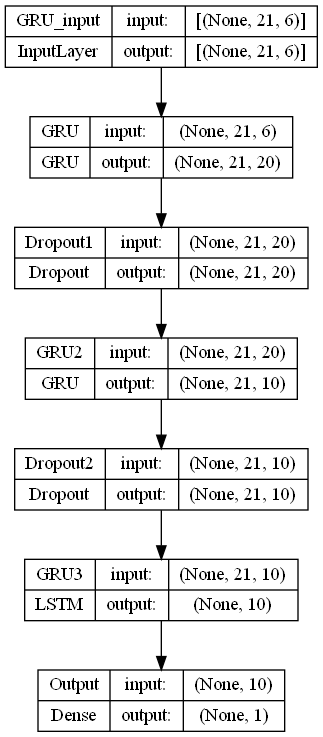

In [112]:
# plot layers
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

In [113]:
# Model fitting
model.fit(g,
          epochs=500, 
          verbose=1, 
          callbacks=my_callbacks, 
          shuffle=False,
          batch_size = 32
          )

Epoch 1/500
11/12 [==========================>...] - ETA: 0s - loss: 0.7021 - accuracy: 0.4780 - precision: 0.4657 - recall: 0.3087
Epoch 1: loss did not improve from 0.55816
12/12 [==============================] - 5s 47ms/step - loss: 0.7021 - accuracy: 0.4720 - precision: 0.4566 - recall: 0.3021
Epoch 2/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6936 - accuracy: 0.5092 - precision: 0.5079 - recall: 0.5519
Epoch 2: loss did not improve from 0.55816
12/12 [==============================] - 0s 40ms/step - loss: 0.6936 - accuracy: 0.5093 - precision: 0.5078 - recall: 0.5628
Epoch 3/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6877 - accuracy: 0.5412 - precision: 0.5336 - recall: 0.6430
Epoch 3: loss did not improve from 0.55816
12/12 [==============================] - 1s 45ms/step - loss: 0.6873 - accuracy: 0.5441 - precision: 0.5356 - recall: 0.6537
Epoch 4/500
12/12 [==============================] - ETA: 0s - loss: 0.6828 - accuracy: 0.5754 - pre

11/12 [==========================>...] - ETA: 0s - loss: 0.6384 - accuracy: 0.6314 - precision: 0.6326 - recall: 0.6245
Epoch 28: loss did not improve from 0.55816
12/12 [==============================] - 1s 46ms/step - loss: 0.6412 - accuracy: 0.6295 - precision: 0.6313 - recall: 0.6203
Epoch 29/500
12/12 [==============================] - ETA: 0s - loss: 0.6411 - accuracy: 0.6282 - precision: 0.6195 - recall: 0.6618
Epoch 29: loss did not improve from 0.55816
12/12 [==============================] - 1s 101ms/step - loss: 0.6411 - accuracy: 0.6282 - precision: 0.6195 - recall: 0.6618
Epoch 30/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6395 - accuracy: 0.6435 - precision: 0.6402 - recall: 0.6529
Epoch 30: loss did not improve from 0.55816
12/12 [==============================] - 1s 83ms/step - loss: 0.6425 - accuracy: 0.6389 - precision: 0.6360 - recall: 0.6471
Epoch 31/500
12/12 [==============================] - ETA: 0s - loss: 0.6443 - accuracy: 0.6262 - precisio

11/12 [==========================>...] - ETA: 0s - loss: 0.6303 - accuracy: 0.6392 - precision: 0.6407 - recall: 0.6316
Epoch 55: loss did not improve from 0.55816
12/12 [==============================] - 1s 73ms/step - loss: 0.6338 - accuracy: 0.6348 - precision: 0.6353 - recall: 0.6310
Epoch 56/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6295 - accuracy: 0.6335 - precision: 0.6365 - recall: 0.6202
Epoch 56: loss did not improve from 0.55816
12/12 [==============================] - 1s 45ms/step - loss: 0.6329 - accuracy: 0.6288 - precision: 0.6304 - recall: 0.6203
Epoch 57/500
12/12 [==============================] - ETA: 0s - loss: 0.6338 - accuracy: 0.6342 - precision: 0.6326 - recall: 0.6377
Epoch 57: loss did not improve from 0.55816
12/12 [==============================] - 1s 52ms/step - loss: 0.6338 - accuracy: 0.6342 - precision: 0.6326 - recall: 0.6377
Epoch 58/500
11/12 [==========================>...] - ETA: 0s - loss: 0.6226 - accuracy: 0.6449 - precision

In [114]:
#evaluate the model on the test data

score_train = model.evaluate(g, verbose=100)

print ('Loss:', round(score_train[0], 3))
print ('Accuracy:', round(score_train[1], 3))
print ('Precision:', round(score_train[2], 3))
print ('Recall:', round(score_train[3], 3))
print (' ')

score_test = model.evaluate(g_, verbose=100)

print ('Loss:', round(score_test[0], 3))
print ('Accuracy:', round(score_test[1], 3))
print ('Precision:', round(score_test[2], 3))
print ('Recall:', round(score_test[3], 3))


Loss: 0.624
Accuracy: 0.648
Precision: 0.637
Recall: 0.683
 
Loss: 0.654
Accuracy: 0.638
Precision: 0.646
Recall: 0.681


## Hyperparameter tuning

In [115]:
def build_model(hp):
    
    tf.keras.backend.clear_session()   

    # instantiate the model
    model = Sequential()
    
    # Tune the number of units in the layers
    hp_units1 = hp.Int('units1', min_value=16, max_value=256, step=16)

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-1, 1e-2, 1e-3, 1e-4])
    
    # Tune lookback value
    hp_lookback = hp.Int('lookback1', min_value=10, max_value=60, step=5)

    # Tune activation functions
    hp_activation1 = hp.Choice(name = 'activation', values = ['sigmoid','tanh','relu', 'elu'], ordered = False)
    
    # Tune Dense layer activation function
    hp_dense_activation1 = hp.Choice(name = 'dense_activation', values = ['sigmoid','relu'])
    
    model.add(LSTM(hp_units1, input_shape=(hp_lookback, numfeat), activation=hp_activation1, return_sequences=False, name='LSTM'))   
    
    model.add(Dense(units=1, activation=hp_dense_activation1, name='Output'))    

    # specify optimizer separately (preferred method))
    opt = Adam(lr=hp_learning_rate, epsilon=1e-08, decay=0.0)       
    
    # model compilation - 'binary_crossentropy' - 'accuracy' - BinaryAccuracy(name='accuracy', threshold=0.5)
    model.compile(optimizer=opt, 
                  loss=BinaryCrossentropy(), 
                  metrics=['accuracy', 
                           Precision(),
                           Recall()])

    return model

In [116]:
# initialize an early stopping callback to prevent the model from
# overfitting/spending too much time training with minimal gains
callback1 = [EarlyStopping(patience=5, monitor='loss', mode='min', verbose=1, restore_best_weights=True),
             TensorBoard(log_dir="./tensorboard/rslogs")]

callback2 = [EarlyStopping(patience=5, monitor='loss', mode='min', verbose=1, restore_best_weights=True),
             TensorBoard(log_dir="./tensorboard/hblogs")]

callback3 = [EarlyStopping(patience=5, monitor='loss', mode='min', verbose=1, restore_best_weights=True),
             TensorBoard(log_dir="./tensorboard/bologs")]

### Approach 1: Random Search

In [117]:
# RandomSearch algorithm from keras tuner
rstuner = RandomSearch(
    build_model,
    objective="val_accuracy",
    max_trials=5,
    directory="./keras",
    project_name="rstrail",
    overwrite=True
)

In [118]:
# launch tuning process
rstuner.search(g, epochs=50, validation_data=g_, callbacks=callback1, shuffle=False)

Trial 2 Complete [00h 00m 17s]
val_accuracy: 0.6601671576499939

Best val_accuracy So Far: 0.6601671576499939
Total elapsed time: 00h 00m 29s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
64                |96                |units1
0.0001            |0.001             |learning_rate
35                |25                |lookback1
relu              |sigmoid           |activation
sigmoid           |relu              |dense_activation

Epoch 1/50
12/12 [==============================] - 4s 85ms/step - loss: 0.6941 - accuracy: 0.4846 - precision: 0.4819 - recall: 0.4278 - val_loss: 0.6958 - val_accuracy: 0.4652 - val_precision: 0.4916 - val_recall: 0.6223
Epoch 2/50
12/12 [==============================] - 0s 31ms/step - loss: 0.6915 - accuracy: 0.5020 - precision: 0.5014 - recall: 0.4733 - val_loss: 0.6935 - val_accuracy: 0.4958 - val_precision: 0.5137 - val_recall: 0.6968
Epoch 3/50
12/12 [==============================] - 0s 26ms/step - loss: 0.6892 - 

FailedPreconditionError: {{function_node __wrapped__MergeV2Checkpoints_device_/job:localhost/replica:0/task:0/device:CPU:0}} Failed to rename: ./keras\rstrail\trial_2\checkpoint_temp/part-00000-of-00001.data-00000-of-00001 to: ./keras\rstrail\trial_2\checkpoint.data-00000-of-00001 : The process cannot access the file because it is being used by another process.
; Broken pipe [Op:MergeV2Checkpoints]

In [119]:
# display the best hyperparameter values for the model based on the defined objective function
best_rshp = rstuner.get_best_hyperparameters()[0]
print(best_rshp.values)

{'units1': 96, 'learning_rate': 0.001, 'lookback1': 25, 'activation': 'sigmoid', 'dense_activation': 'relu'}


### Approach 2: BayesianOptimization

In [120]:
# BayesianOptimization algorithm from keras tuner
botuner = BayesianOptimization(
    build_model,
    objective="val_accuracy",
    max_trials=15,
    num_initial_points=2,
    hyperparameters=None,
    tune_new_entries=True,
    allow_new_entries=True,
    overwrite=True,
    directory="./keras",
    project_name="botrial")

In [121]:
# launch tuning process
botuner.search(g, epochs=50, validation_data=g_, callbacks=callback3, shuffle=False)

Trial 9 Complete [00h 00m 30s]
val_accuracy: 0.6434540152549744

Best val_accuracy So Far: 0.6573815941810608
Total elapsed time: 00h 06m 41s

Search: Running Trial #10

Value             |Best Value So Far |Hyperparameter
256               |160               |units1
0.0001            |0.001             |learning_rate
10                |45                |lookback1
sigmoid           |elu               |activation
sigmoid           |sigmoid           |dense_activation

Epoch 1/50
12/12 [==============================] - 4s 175ms/step - loss: 0.7477 - accuracy: 0.5007 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_loss: 0.7026 - val_accuracy: 0.4763 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/50
12/12 [==============================] - 1s 81ms/step - loss: 0.6946 - accuracy: 0.4973 - precision: 0.4972 - recall: 0.5936 - val_loss: 0.6926 - val_accuracy: 0.5237 - val_precision: 0.5237 - val_recall: 1.0000
Epoch 3/50
12/12 [==============================] - 1s 89ms/step

FailedPreconditionError: {{function_node __wrapped__MergeV2Checkpoints_device_/job:localhost/replica:0/task:0/device:CPU:0}} Failed to rename: ./keras\botrial\trial_09\checkpoint_temp/part-00000-of-00001.data-00000-of-00001 to: ./keras\botrial\trial_09\checkpoint.data-00000-of-00001 : The process cannot access the file because it is being used by another process.
; Broken pipe [Op:MergeV2Checkpoints]

In [ ]:
# display the best hyperparameter values for the model based on the defined objective function
best_bohp = botuner.get_best_hyperparameters()[0]
print(best_bohp.values)

# Model evaluation and backtesting

In [ ]:
# Create a sequential model
def create_model(hu=16, lookback=50, features=numfeat):
    
    tf.keras.backend.clear_session()

    # instantiate the model
    model = Sequential()
    
    model.add(LSTM(units=hu, input_shape=(lookback, features), activation = 'sigmoid', return_sequences=False, name='LSTM'))
    
    model.add(Dense(units=1, activation = 'sigmoid', name='Output'))             
      
    # specify optimizer separately 
    opt = Adam(lr=0.001, epsilon=1e-08, decay=0.0)       
    
    # model compilation - 'binary_crossentropy' - 'accuracy' - BinaryAccuracy(name='accuracy', threshold=0.5)
    model.compile(optimizer=opt, 
                  loss=BinaryCrossentropy(), 
                  metrics=['accuracy', 
                           Precision(),
                           Recall()])

    return model

In [ ]:
# lstm network
model = create_model(hu=16, lookback=50, features=numfeat)

In [ ]:
# summary
model.summary()

### Model plot

In [ ]:
# plot layers
plot_model(model, to_file='model.png', show_shapes=True, show_layer_names=True)

### Model Fitting

In [ ]:
# Model fitting
model.fit(g,
          epochs=50,
          verbose=1,
          callbacks=my_callbacks,
          shuffle=False,
          batch_size=32
              )

In [ ]:
#evaluate the model on the test data

score_train = model.evaluate(g, verbose=100)

print ('Loss:', round(score_train[0], 3))
print ('Accuracy:', round(score_train[1], 3))
print ('Precision:', round(score_train[2], 3))
print ('Recall:', round(score_train[3], 3))
print (' ')

score_test = model.evaluate(g_, verbose=100)

print ('Loss:', round(score_test[0], 3))
print ('Accuracy:', round(score_test[1], 3))
print ('Precision:', round(score_test[2], 3))
print ('Recall:', round(score_test[3], 3))


### Confusion Matrix

In [ ]:
y_test[21:].shape
y_test2 = y_test[21:]

In [ ]:
y_pred_prob = model.predict(g_)
y_pred_prob

In [ ]:
y_pred_list = []
for i in y_pred_prob:
    if i> 0.5:
        y_pred_list.append(1)
    else:
        y_pred_list.append(0)


In [ ]:
y_pred = np.array(y_pred_list)
y_pred.shape

In [ ]:
# Confusion Matrix for binary classification, dropping the first 21 because they were used in sequence creation
tn, fp, fn, tp = confusion_matrix(y_test[21:], y_pred).ravel()
print(tn, fp, fn, tp)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix

labels = labels = ["0", "1"]

cm = confusion_matrix(y_test2, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

## Classification Report
The classification report is used to measure the quality of predictions from a classification algorithm.

In [ ]:
# Classification Report
print(classification_report(y_test2, y_pred))

## Receiver Operator Characterisitc Curve (ROC)
The ROC curve plots the true positive rate (TPR) against the false positive rate (FPR) at various classification thresholds. 
### Area Under ROC Curve
The area under the ROC curve (AUC) is a measure of how well a model can distinguish between two classes.

In [ ]:
fpr_keras, tpr_keras, thresholds_keras = roc_curve(y_test2, y_pred)
from sklearn.metrics import auc
auc_keras = auc(fpr_keras, tpr_keras)



In [ ]:
plt.figure(1)
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_keras, tpr_keras, label='Model (AuC = {:.3f})'.format(auc_keras))

plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc=9)
plt.show()

## Backtesting

In [ ]:
X4

In [ ]:
df2 = yf.download('CUKX.L',start='2015-01-01', end='2023-01-10', progress=0)
df2['Forward Returns'] = np.log(df['Adj Close']).diff().shift(-1)

df2 = df2.dropna()
df2 = df2[:-25]
df2

In [ ]:
df3 = df2[-359:]
df3

In [ ]:
df3.shape

In [ ]:
df3['Signal'] = y_pred

# Strategy Returns
df3['Strategy'] = df3['Forward Returns'] * df3['Signal'].fillna(0)

# Localize index for pyfolio
df3.index = df3.index.tz_localize('utc')

In [ ]:
df3

In [ ]:
# plot 
plt.plot(np.cumsum(df3['Strategy']), 'r-',label='Strategy')
plt.plot(np.cumsum(df3['Forward Returns']),'blue',label='Forward Returns')
plt.title('Strategy vs Forward Returns')
plt.legend()

## Return Analysis


In [ ]:
# Import pyfolio
import pyfolio as pf

In [ ]:
# Create Tear sheet using pyfolio for outsample - for X_test
pf.create_simple_tear_sheet(df3['Strategy'])

In [ ]:
pf.plot_monthly_returns_heatmap(df3['Strategy'])

In [ ]:
pf.plot_annual_returns(df3['Strategy'])

In [ ]:
pf.plot_monthly_returns_dist(df3['Strategy'])